# IPL Team-by-Team Time Series Forecasting Notebook

## 1. Objective
This notebook performs **team-by-team time-series forecasting** for IPL teams and expands the earlier workflow with more time-series features and diagnostics. It predicts future team performance using:

- ARIMA (AutoRegressive Integrated Moving Average)
- SARIMA / SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)
- Prophet (Prophet forecasting model)

## 2. Key Additions
- Added opponent and venue as exogenous variables in the SARIMAX model.
- Built separate pipelines for runs, wickets, and win-probability proxy.
- Compared match-level and season-level forecasting approaches.
- Included confidence intervals and residual diagnostics for model evaluation.

## Abbreviations used

This notebook uses several shorthand forms for models, metrics, and IPL team codes. The expanded forms are:

- ARIMA: AutoRegressive Integrated Moving Average.
- SARIMAX: Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors.
- Prophet: Prophet forecasting model.
- MAE: Mean Absolute Error.
- RMSE: Root Mean Squared Error.
- MAPE: Mean Absolute Percentage Error.
- Team codes: CSK (Chennai Super Kings), DC (Delhi Capitals), GL (Gujarat Lions), GT (Gujarat Titans), KKR (Kolkata Knight Riders), KTK (Kochi Tuskers Kerala), LSG (Lucknow Super Giants), MI (Mumbai Indians), PBKS (Punjab Kings), PWI (Pune Warriors India), RCB (Royal Challengers Bengaluru), RPS (Rising Pune Supergiant), RR (Rajasthan Royals), SRH (Sunrisers Hyderabad).

## 3. Workflow
For each team, this notebook will:

1. Build match-level and season-level time series.
2. Engineer run, wicket, win, opponent, and venue features.
3. Train ARIMA (AutoRegressive Integrated Moving Average), SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors), and Prophet (Prophet forecasting model) models.
4. Evaluate model performance with MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and MAPE (Mean Absolute Percentage Error).
5. Generate future forecasts.
6. Store model comparison outputs for all teams.

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception:
    PROPHET_AVAILABLE = False

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

## 4. Load IPL datasets
The notebook uses the provided cleaned match-level and ball-level IPL data.

In [22]:
matches = pd.read_csv("clean_matches.csv")
deliveries = pd.read_csv("clean_deliveries.csv")

matches['match_date'] = pd.to_datetime(matches['match_date'])

print('matches shape   :', matches.shape)
print('deliveries shape:', deliveries.shape)

matches shape   : (1169, 24)
deliveries shape: (278205, 30)


## 5. Team universe
All teams available in the delivery data are included in the team-by-team modeling loop.

In [23]:
teams = sorted(deliveries['team_batting'].dropna().unique())
print(teams)

['CSK', 'DC', 'GL', 'GT', 'KKR', 'KTK', 'LSG', 'MI', 'PBKS', 'PWI', 'RCB', 'RPS', 'RR', 'SRH']


## 6. Helper functions
These utility functions are reused across all forecasting pipelines.

In [24]:
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(y_true, y_pred, team, target_name, model_name, granularity):
    return {
        'Team': team,
        'Target': target_name,
        'Granularity': granularity,
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': safe_mape(y_true, y_pred)
    }


def adf_test_summary(series):
    series = pd.Series(series).dropna()
    if len(series) < 8:
        return {'adf_statistic': np.nan, 'p_value': np.nan}
    out = adfuller(series)
    return {'adf_statistic': out[0], 'p_value': out[1]}

## 7. Build match-level team dataset
This function creates a chronological team-level dataset with runs, wickets, win indicators, and exogenous variables such as opponent and venue.

In [25]:
def build_team_match_df(team, matches, deliveries):
    team_balls = deliveries.loc[deliveries['team_batting'] == team].copy()
    team_runs = team_balls.groupby('match_id', as_index=False).agg(team_runs=('total_runs', 'sum'))
    team_wickets = team_balls.groupby('match_id', as_index=False).agg(team_wickets_lost=('is_wicket', 'sum'))

    team_matches = matches.loc[(matches['team1'] == team) | (matches['team2'] == team)].copy()
    team_matches['opponent'] = np.where(team_matches['team1'] == team, team_matches['team2'], team_matches['team1'])
    team_matches['team_win'] = (team_matches['match_winner'] == team).astype(int)
    team_matches['is_home_city_known'] = team_matches['city'].notna().astype(int)
    team_matches['toss_win_flag'] = (team_matches['toss_winner'] == team).astype(int)
    team_matches['bat_first_flag'] = ((team_matches['team1'] == team) & (team_matches['toss_decision'] == 'bat')).astype(int)

    boundary_stats = (
        team_balls.assign(is_boundary=team_balls['batter_runs'].isin([4, 6]).astype(int))
        .groupby('match_id', as_index=False)
        .agg(boundary_frequency=('is_boundary', 'mean'))
    )

    death_stats = (
        team_balls.loc[team_balls['over_number'] >= 15]
        .groupby('match_id', as_index=False)
        .agg(death_over_runs=('total_runs', 'sum'))
    )

    df = (
        team_matches[['match_id', 'match_date', 'season_id', 'venue', 'city', 'opponent', 'team_win', 'is_home_city_known', 'toss_win_flag', 'bat_first_flag']]
        .merge(team_runs, on='match_id', how='inner')
        .merge(team_wickets, on='match_id', how='left')
        .merge(boundary_stats, on='match_id', how='left')
        .merge(death_stats, on='match_id', how='left')
        .sort_values('match_date')
        .reset_index(drop=True)
    )

    df['death_over_runs'] = df['death_over_runs'].fillna(0)
    df['boundary_frequency'] = df['boundary_frequency'].fillna(0)
    df['rolling_runs_3'] = df['team_runs'].rolling(3).mean()
    df['rolling_runs_5'] = df['team_runs'].rolling(5).mean()
    df['rolling_wickets_3'] = df['team_wickets_lost'].rolling(3).mean()
    df['rolling_win_rate_5'] = df['team_win'].rolling(5).mean()
    df['lag_runs_1'] = df['team_runs'].shift(1)
    df['lag_runs_2'] = df['team_runs'].shift(2)
    df['lag_wickets_1'] = df['team_wickets_lost'].shift(1)
    df['run_momentum'] = df['team_runs'].diff()
    df['wicket_momentum'] = df['team_wickets_lost'].diff()
    df['match_seq'] = np.arange(len(df))
    df['sin_5'] = np.sin(2 * np.pi * df['match_seq'] / 5)
    df['cos_5'] = np.cos(2 * np.pi * df['match_seq'] / 5)

    return df

## 8. Build season-level team dataset
This aggregation is used to compare match-level forecasting against season-level forecasting.

In [26]:
def build_team_season_df(team_match_df):
    season_df = (
        team_match_df.groupby('season_id', as_index=False)
        .agg(
            season_runs=('team_runs', 'sum'),
            season_wickets=('team_wickets_lost', 'sum'),
            season_win_rate=('team_win', 'mean'),
            mean_boundary_frequency=('boundary_frequency', 'mean'),
            mean_death_over_runs=('death_over_runs', 'mean')
        )
        .sort_values('season_id')
        .reset_index(drop=True)
    )
    season_df['season_seq'] = np.arange(len(season_df))
    season_df['lag_runs_1'] = season_df['season_runs'].shift(1)
    season_df['lag_wickets_1'] = season_df['season_wickets'].shift(1)
    season_df['sin_3'] = np.sin(2 * np.pi * season_df['season_seq'] / 3)
    season_df['cos_3'] = np.cos(2 * np.pi * season_df['season_seq'] / 3)
    return season_df

## 9. Target setup
Three separate forecasting targets are modeled:

1. Team runs scored.
2. Team wickets lost.
3. Team win probability proxy.

In [27]:
def get_target_series(df, target_name, granularity='match'):
    if granularity == 'match':
        mapping = {
            'runs': 'team_runs',
            'wickets': 'team_wickets_lost',
            'win_probability_proxy': 'team_win'
        }
        time_col = 'match_date'
    else:
        mapping = {
            'runs': 'season_runs',
            'wickets': 'season_wickets',
            'win_probability_proxy': 'season_win_rate'
        }
        time_col = 'season_id'

    target_col = mapping[target_name]
    return target_col, time_col

## 10. Exogenous variable preparation for SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors)
SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) can use external drivers of the time series. Here, venue and opponent are encoded for match-level forecasting, and boundary/death-over summaries are used for season-level forecasting.

In [28]:
def build_exog(df, granularity='match'):
    if granularity == 'match':
        exog = pd.get_dummies(
            df[['opponent', 'venue']],
            prefix=['opp', 'venue'],
            drop_first=True,
            dtype=float
        )
        numeric = df[['toss_win_flag', 'bat_first_flag', 'boundary_frequency', 'death_over_runs']].fillna(0)
        exog = pd.concat([numeric.reset_index(drop=True), exog.reset_index(drop=True)], axis=1)
    else:
        exog = df[['mean_boundary_frequency', 'mean_death_over_runs']].fillna(0).copy()
    return exog

## 11. Forecasting function
This function fits ARIMA (AutoRegressive Integrated Moving Average), SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors), and Prophet (Prophet forecasting model) for a chosen target and granularity, then returns evaluation results, future forecasts, confidence intervals, and residuals where available.

In [29]:
def run_forecasting_pipeline(df, team, target_name='runs', granularity='match', forecast_horizon=5):
    target_col, time_col = get_target_series(df, target_name, granularity)

    model_df = df.copy()
    if granularity == 'match':
        model_df = model_df.sort_values(time_col).set_index(time_col)
    else:
        model_df = model_df.sort_values(time_col).set_index(time_col)

    series = model_df[target_col].dropna()
    if len(series) < 12:
        return None, None, None, None

    exog = build_exog(df.loc[series.index] if granularity == 'season' else model_df.reset_index().loc[model_df.reset_index()[time_col].isin(series.index)], granularity)
    exog.index = series.index

    split_idx = int(len(series) * 0.8)
    train_y, test_y = series.iloc[:split_idx], series.iloc[split_idx:]
    train_exog, test_exog = exog.iloc[:split_idx], exog.iloc[split_idx:]

    results = []
    future_frames = []
    residual_store = {}
    interval_store = {}

    try:
        arima_fit = ARIMA(train_y, order=(2, 1, 2)).fit()
        pred_arima = arima_fit.forecast(steps=len(test_y))
        pred_arima.index = test_y.index
        results.append(evaluate_model(test_y, pred_arima, team, target_name, 'ARIMA', granularity))
        residual_store['ARIMA'] = arima_fit.resid

        arima_future = arima_fit.get_forecast(steps=forecast_horizon)
        arima_mean = arima_future.predicted_mean
        arima_ci = arima_future.conf_int()
        future_frames.append(pd.DataFrame({
            'Team': team,
            'Target': target_name,
            'Granularity': granularity,
            'Model': 'ARIMA',
            'Step': np.arange(1, forecast_horizon + 1),
            'Forecast': arima_mean.values,
            'Lower_CI': arima_ci.iloc[:, 0].values,
            'Upper_CI': arima_ci.iloc[:, 1].values
        }))
        interval_store['ARIMA'] = arima_ci
    except Exception:
        pass

    try:
        sarimax_fit = SARIMAX(
            train_y,
            exog=train_exog,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 5),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        pred_sarimax = sarimax_fit.forecast(steps=len(test_y), exog=test_exog)
        pred_sarimax.index = test_y.index
        results.append(evaluate_model(test_y, pred_sarimax, team, target_name, 'SARIMAX', granularity))
        residual_store['SARIMAX'] = sarimax_fit.resid

        future_exog = pd.DataFrame(np.tile(train_exog.iloc[-1].values, (forecast_horizon, 1)), columns=train_exog.columns)
        sarimax_future = sarimax_fit.get_forecast(steps=forecast_horizon, exog=future_exog)
        sarimax_mean = sarimax_future.predicted_mean
        sarimax_ci = sarimax_future.conf_int()
        future_frames.append(pd.DataFrame({
            'Team': team,
            'Target': target_name,
            'Granularity': granularity,
            'Model': 'SARIMAX',
            'Step': np.arange(1, forecast_horizon + 1),
            'Forecast': sarimax_mean.values,
            'Lower_CI': sarimax_ci.iloc[:, 0].values,
            'Upper_CI': sarimax_ci.iloc[:, 1].values
        }))
        interval_store['SARIMAX'] = sarimax_ci
    except Exception:
        pass

    try:
        if PROPHET_AVAILABLE and granularity == 'match':
            prophet_df = model_df.reset_index()[[time_col, target_col]].rename(columns={time_col: 'ds', target_col: 'y'})
            train_prophet = prophet_df.iloc[:split_idx].copy()
            test_prophet = prophet_df.iloc[split_idx:].copy()
            prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
            prophet_model.fit(train_prophet)
            future = prophet_model.make_future_dataframe(periods=len(test_prophet), include_history=True)
            prophet_pred_full = prophet_model.predict(future)
            prophet_pred = prophet_pred_full[prophet_pred_full['ds'].isin(test_prophet['ds'])].sort_values('ds')
            if len(prophet_pred) == len(test_prophet):
                results.append(evaluate_model(test_prophet['y'].values, prophet_pred['yhat'].values, team, target_name, 'Prophet', granularity))

            prophet_future_dates = prophet_model.make_future_dataframe(periods=forecast_horizon, include_history=False)
            prophet_future = prophet_model.predict(prophet_future_dates)
            future_frames.append(pd.DataFrame({
                'Team': team,
                'Target': target_name,
                'Granularity': granularity,
                'Model': 'Prophet',
                'Step': np.arange(1, min(forecast_horizon, len(prophet_future)) + 1),
                'Forecast': prophet_future['yhat'].values[:forecast_horizon],
                'Lower_CI': prophet_future['yhat_lower'].values[:forecast_horizon],
                'Upper_CI': prophet_future['yhat_upper'].values[:forecast_horizon]
            }))
        elif PROPHET_AVAILABLE and granularity == 'season':
            prophet_df = model_df.reset_index()[[time_col, target_col]].copy()
            prophet_df['ds'] = pd.to_datetime(prophet_df[time_col].astype(str) + '-01-01')
            prophet_df['y'] = prophet_df[target_col]
            prophet_df = prophet_df[['ds', 'y']]
            train_prophet = prophet_df.iloc[:split_idx].copy()
            test_prophet = prophet_df.iloc[split_idx:].copy()
            prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
            prophet_model.fit(train_prophet)
            future = prophet_model.make_future_dataframe(periods=len(test_prophet), freq='Y', include_history=True)
            prophet_pred_full = prophet_model.predict(future)
            prophet_pred = prophet_pred_full.tail(len(test_prophet))
            if len(prophet_pred) == len(test_prophet):
                results.append(evaluate_model(test_prophet['y'].values, prophet_pred['yhat'].values, team, target_name, 'Prophet', granularity))

            prophet_future_dates = prophet_model.make_future_dataframe(periods=forecast_horizon, freq='Y', include_history=False)
            prophet_future = prophet_model.predict(prophet_future_dates)
            future_frames.append(pd.DataFrame({
                'Team': team,
                'Target': target_name,
                'Granularity': granularity,
                'Model': 'Prophet',
                'Step': np.arange(1, min(forecast_horizon, len(prophet_future)) + 1),
                'Forecast': prophet_future['yhat'].values[:forecast_horizon],
                'Lower_CI': prophet_future['yhat_lower'].values[:forecast_horizon],
                'Upper_CI': prophet_future['yhat_upper'].values[:forecast_horizon]
            }))
    except Exception:
        pass

    results_df = pd.DataFrame(results)
    forecast_df = pd.concat(future_frames, ignore_index=True) if future_frames else pd.DataFrame()
    return results_df, forecast_df, residual_store, interval_store

## 12. Run all team-by-team pipelines
The notebook now runs multiple forecasting pipelines for every team and for multiple targets.

In [30]:
all_results = []
all_forecasts = []
team_data_store = {}
residual_diagnostics_store = {}

for team in teams:
    print(f'Processing team: {team}')
    match_df = build_team_match_df(team, matches, deliveries)
    season_df = build_team_season_df(match_df)
    team_data_store[(team, 'match')] = match_df
    team_data_store[(team, 'season')] = season_df

    for target_name in ['runs', 'wickets', 'win_probability_proxy']:
        for granularity, input_df in [('match', match_df), ('season', season_df)]:
            try:
                results_df, forecast_df, residuals, intervals = run_forecasting_pipeline(
                    input_df,
                    team=team,
                    target_name=target_name,
                    granularity=granularity,
                    forecast_horizon=5
                )
                if results_df is not None and not results_df.empty:
                    all_results.append(results_df)
                if forecast_df is not None and not forecast_df.empty:
                    all_forecasts.append(forecast_df)
                residual_diagnostics_store[(team, target_name, granularity)] = residuals
            except Exception as e:
                print(f'  Failed for {team} | {target_name} | {granularity}: {e}')

Processing team: CSK


18:20:17 - cmdstanpy - INFO - Chain [1] start processing
18:20:17 - cmdstanpy - INFO - Chain [1] done processing


  Failed for CSK | runs | season: "None of [Index([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype='int64', name='season_id')] are in the [index]"


18:20:19 - cmdstanpy - INFO - Chain [1] start processing
18:20:19 - cmdstanpy - INFO - Chain [1] done processing


  Failed for CSK | wickets | season: "None of [Index([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype='int64', name='season_id')] are in the [index]"


...

  Failed for SRH | runs | season: "None of [RangeIndex(start=2008, stop=2026, step=1, name='season_id')] are in the [index]"


18:21:25 - cmdstanpy - INFO - Chain [1] start processing
18:21:25 - cmdstanpy - INFO - Chain [1] done processing


  Failed for SRH | wickets | season: "None of [RangeIndex(start=2008, stop=2026, step=1, name='season_id')] are in the [index]"


18:21:28 - cmdstanpy - INFO - Chain [1] start processing
18:21:28 - cmdstanpy - INFO - Chain [1] done processing


  Failed for SRH | win_probability_proxy | season: "None of [RangeIndex(start=2008, stop=2026, step=1, name='season_id')] are in the [index]"


## 13. Combined evaluation results
This table compares all models across teams, targets, and time granularities.

In [31]:
results_master = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
results_master = results_master.sort_values(['Team', 'Target', 'Granularity', 'RMSE', 'MAE']).reset_index(drop=True)
results_master.head(50)

,Team,Target,Granularity,Model,MAE,RMSE,MAPE
0,CSK,runs,match,SARIMAX,14.186111,16.835353,8.053681
1,CSK,runs,match,ARIMA,26.372485,33.607551,14.873364
2,CSK,wickets,match,ARIMA,1.584324,2.036151,28.526778
3,CSK,wickets,match,SARIMAX,1.996443,2.337754,39.075103
4,CSK,win_probability_proxy,match,ARIMA,0.507704,0.516045,41.135781
5,CSK,win_probability_proxy,match,SARIMAX,0.485547,0.528085,54.779016
6,DC,runs,match,SARIMAX,11.374660,17.214855,7.735156
7,DC,runs,match,ARIMA,28.626528,35.409578,16.529991
8,DC,wickets,match,ARIMA,2.381639,2.674225,53.323867
9,DC,wickets,match,SARIMAX,2.822647,3.451727,51.195503


## 14. Best model per team and target
The best model is selected using lowest RMSE (Root Mean Squared Error).

In [32]:
best_models = (
    results_master.sort_values(['Team', 'Target', 'Granularity', 'RMSE', 'MAE'])
    .groupby(['Team', 'Target', 'Granularity'], as_index=False)
    .first()
)
best_models.head(50)

,Team,Target,Granularity,Model,MAE,RMSE,MAPE
0,CSK,runs,match,SARIMAX,14.186111,16.835353,8.053681
1,CSK,wickets,match,ARIMA,1.584324,2.036151,28.526778
2,CSK,win_probability_proxy,match,ARIMA,0.507704,0.516045,41.135781
3,DC,runs,match,SARIMAX,11.374660,17.214855,7.735156
4,DC,wickets,match,ARIMA,2.381639,2.674225,53.323867
5,DC,win_probability_proxy,match,ARIMA,0.487291,0.489718,48.017498
6,GL,runs,match,ARIMA,21.642448,28.062386,11.173902
7,GL,wickets,match,ARIMA,2.530376,2.807866,32.246445
8,GL,win_probability_proxy,match,ARIMA,0.416051,0.432846,53.458422
9,GT,runs,match,SARIMAX,9.528452,13.146720,5.019517


## 15. Future forecasts with confidence intervals
This table stores future predictions and associated uncertainty ranges.

In [33]:
forecasts_master = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()
forecasts_master.head(50)

,Team,Target,Granularity,Model,Step,Forecast,Lower_CI,Upper_CI
0,CSK,runs,match,ARIMA,1,159.787786,100.167842,219.407730
1,CSK,runs,match,ARIMA,2,161.128163,101.444079,220.812247
2,CSK,runs,match,ARIMA,3,160.050645,100.316444,219.784846
3,CSK,runs,match,ARIMA,4,160.963203,101.209554,220.716853
4,CSK,runs,match,ARIMA,5,160.189910,100.408423,219.971397
5,CSK,runs,match,SARIMAX,1,176.398158,153.431221,199.365095
6,CSK,runs,match,SARIMAX,2,176.396030,152.805728,199.986333
7,CSK,runs,match,SARIMAX,3,177.418288,153.737663,201.098913
8,CSK,runs,match,SARIMAX,4,176.821036,153.096731,200.545340
9,CSK,runs,match,SARIMAX,5,174.453559,150.692536,198.214583


## 16. Residual diagnostics example
Residual analysis helps confirm whether the model errors behave like white noise. This section shows a sample residual diagnostic plot for one team and target.

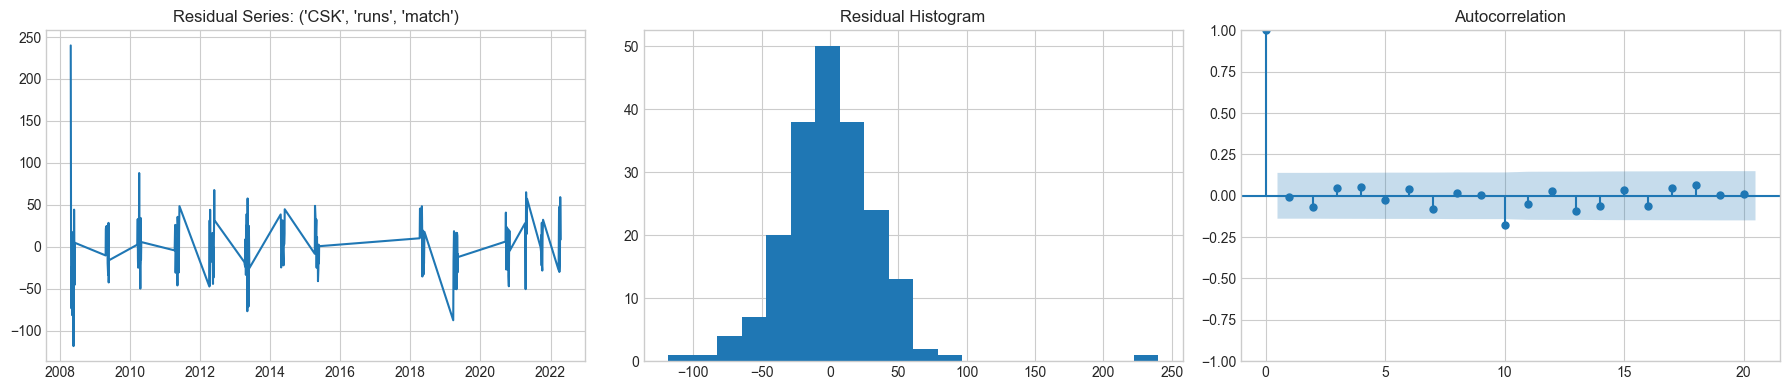

In [34]:
sample_key = None
for key, value in residual_diagnostics_store.items():
    if value and 'ARIMA' in value:
        sample_key = key
        break

if sample_key is not None:
    sample_resid = pd.Series(residual_diagnostics_store[sample_key]['ARIMA']).dropna()
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(sample_resid)
    axes[0].set_title(f'Residual Series: {sample_key}')
    axes[1].hist(sample_resid, bins=20)
    axes[1].set_title('Residual Histogram')
    plot_acf(sample_resid, ax=axes[2], lags=min(20, len(sample_resid)-1))
    plt.tight_layout()
    plt.show()

## 17. Match-level vs season-level comparison
This summary helps compare whether match-level forecasting or season-level forecasting is more stable for each target.

In [35]:
comparison_summary = (
    results_master.groupby(['Target', 'Granularity', 'Model'], as_index=False)
    .agg(avg_rmse=('RMSE', 'mean'), avg_mae=('MAE', 'mean'), avg_mape=('MAPE', 'mean'))
    .sort_values(['Target', 'Granularity', 'avg_rmse'])
)
comparison_summary

,Target,Granularity,Model,avg_rmse,avg_mae,avg_mape
1,runs,match,SARIMAX,24.537999,19.338682,14.232583
0,runs,match,ARIMA,36.470027,29.363050,20.529421
2,wickets,match,ARIMA,2.699293,2.242020,57.892016
3,wickets,match,SARIMAX,3.368786,2.817867,60.606314
4,win_probability_proxy,match,ARIMA,0.513275,0.498983,53.325420
5,win_probability_proxy,match,SARIMAX,0.659557,0.547491,59.450424


## 18. Example trend plot for one team
This chart helps communicate the underlying team performance trend visually.

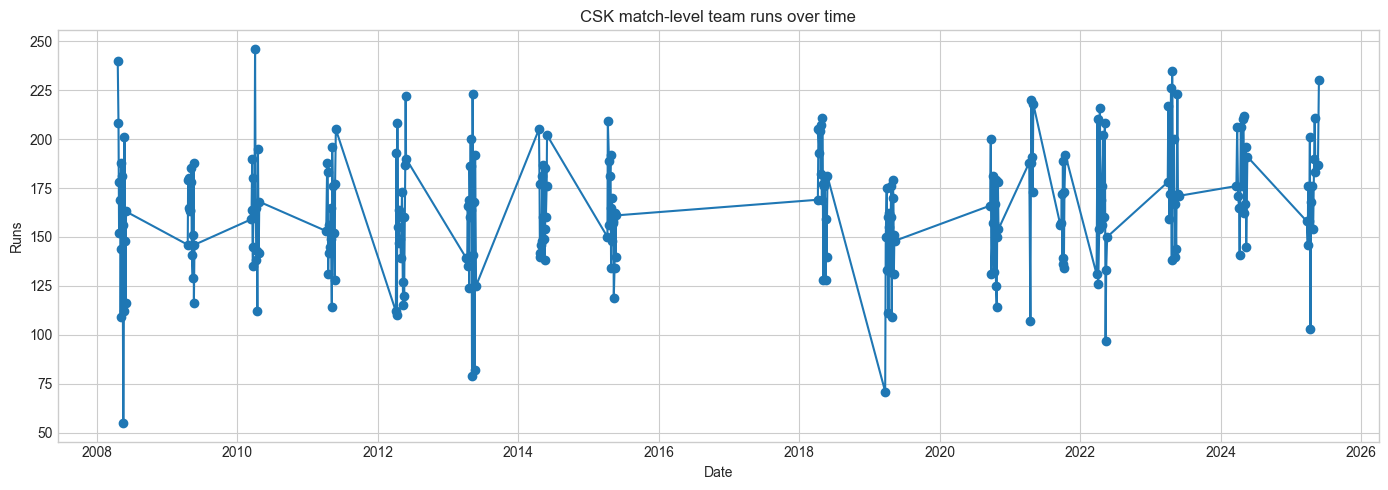

In [36]:
example_team = teams[0]
example_match_df = team_data_store[(example_team, 'match')]

plt.figure(figsize=(14, 5))
plt.plot(example_match_df['match_date'], example_match_df['team_runs'], marker='o', linewidth=1.5)
plt.title(f'{example_team} match-level team runs over time')
plt.xlabel('Date')
plt.ylabel('Runs')
plt.tight_layout()
plt.show()

## 19. Export outputs
The notebook saves the master result tables for later use.

In [37]:
from pathlib import Path

# Create output directory
output_dir = Path('./output')

output_dir.mkdir(exist_ok=True)

results_path = output_dir / 'ipl_team_timeseries_results.csv'

forecasts_path = output_dir / 'ipl_team_timeseries_forecasts.csv'

best_models_path = output_dir / 'ipl_team_timeseries_best_models.csv'

comparison_path = output_dir / 'ipl_team_timeseries_comparison.csv'

# Save CSV files
results_master.to_csv(results_path, index=False)

forecasts_master.to_csv(forecasts_path, index=False)

best_models.to_csv(best_models_path, index=False)

comparison_summary.to_csv(comparison_path, index=False)

# Print saved file paths
print(results_path)

print(forecasts_path)

print(best_models_path)

print(comparison_path)

output/ipl_team_timeseries_results.csv
output/ipl_team_timeseries_forecasts.csv
output/ipl_team_timeseries_best_models.csv
output/ipl_team_timeseries_comparison.csv
